**<h1 align="center">Universidad Internacional del Ecuador</h1>**

**<h2 align="center">Visión por Computador</h2>**

***<h3 align="left">Grupo 8</h3>***
- ***<h3 align="left">DARIO WLADIMIR HERRERA CHÁVEZ</h3>***
- ***<h3 align="left">FABIAN PATRICIO AGUIRRE PAREJA</h3>***
- ***<h3 align="left">JORGE ARMANDO QUIZAMANCHURO FUEL</h3>***
- ***<h3 align="left">JONATHAN ANDRES VASCO CALVACHE</h3>***

> *Repositorio*
>
> https://github.com/daros10/UIDE-Vision-Por-Computador-Homework-3

## - Detección de Objetos en Tiempo Real con YOLO

El presente entregable tiene como objetivo diseñar una aplicación específica de detección de objetos utilizando el modelo YOLO (You Only Look Once), enfocada en un conjunto limitado de clases. El sistema debe demostrar que únicamente detecta las clases previamente activadas, ignorando visualmente aquellos objetos que pertenecen a clases desactivadas, incluso si estos están presentes en la imagen.

## - Desarrollo

### *1. Definición de la aplicación y el problema a resolver*

El problema a resolver es la seguridad dentro de la vivienda. La aplicación propuesta consiste en un sistema de detección de intrusiones capaz de identificar accesos no autorizados en zonas específicas definidas por el usuario.

El sistema permite establecer áreas restringidas dentro del entorno y detectar la presencia de personas (primera categoría). Adicionalmente, se consideran “objetos de valor” como segunda categoría, incluyendo clases como teléfono y computador. Estas clases pueden ampliarse y personalizarse según las necesidades, aunque para fines académicos se utilizarán únicamente las mencionadas.

El aplicativo es capaz de detectar una intrusión cuando una persona ingresa a un área delimitada, generando una alerta. Esto permite a los usuarios contar con un sistema de seguridad más flexible y personalizado, basado en zonas de interés definidas por ellos mismos, en lugar de depender únicamente de soluciones tradicionales pre-configuradas.

### *2. Selección de clases de YOLO*

Como ya se indicó en la definición del problema, las clases a utilizarse son:
- Persona
- Celular
- Laptop

### *4. Filtrado de clases de YOLO*

Dentro de la solución al problema únicamente se visualizarán las clases descritas, filtrando/desactivando el resto de clases conocidas por el modelo de YOLO.

### *5. Solución / Resultados*

In [1]:
from ultralytics import YOLO
import cv2
import time

model = YOLO("yolo26n.pt")

TARGET_CLASSES = [0, 63, 67]

CLASS_NAMES = {
    0: "Person",
    63: "Laptop",
    67: "Phone"
}

USE_CONFIDENCE = True
CONF_THRESHOLD = 0.4

cap = cv2.VideoCapture(0)

# Zone Vars
drawing = False
ix, iy = -1, -1
zone_to_check = None

def draw_box(event, x, y, flags, param):
    global ix, iy, drawing, zone_to_check

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        ix, iy = x, y

    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            zone_to_check = (ix, iy, x, y)

    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        zone_to_check = (ix, iy, x, y)


cv2.namedWindow("System")
cv2.setMouseCallback("System", draw_box)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    alert = False

    if zone_to_check:
        zx1, zy1, zx2, zy2 = zone_to_check

        zx1, zx2 = min(zx1, zx2), max(zx1, zx2)
        zy1, zy2 = min(zy1, zy2), max(zy1, zy2)

        overlay = frame.copy()
        cv2.rectangle(overlay, (zx1, zy1), (zx2, zy2), (255, 0, 0), -1)
        cv2.addWeighted(overlay, 0.2, frame, 0.8, 0, frame)

        cv2.rectangle(frame, (zx1, zy1), (zx2, zy2), (255, 0, 0), 2)
        cv2.putText(frame, "Restricted Zone", (zx1, zy1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    for r in results:
        for box in r.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])

            if class_id not in TARGET_CLASSES:
                print(f"Ignores classes, only accept ${TARGET_CLASSES}")
                continue

            if USE_CONFIDENCE and confidence < CONF_THRESHOLD:
                print("Confidence lower than threshold")
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            inside = False

            if zone_to_check and class_id == 0:
                if not (x2 < zx1 or x1 > zx2 or y2 < zy1 or y1 > zy2):
                    inside = True
                    alert = True

            if class_id == 0:
                color = (0, 0, 255) if inside else (0, 255, 0)
            else:
                color = (255, 255, 0)

            label = CLASS_NAMES.get(class_id, "Unknown")

            if USE_CONFIDENCE:
                texto = f"{label} {confidence:.2f}"
            else:
                texto = label

            if inside and class_id == 0:
                texto = f"INTRUSION {confidence:.2f}"

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, texto, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    if alert:
        if int(time.time() * 2) % 2 == 0:
            alert_text = "ALERT!"

            (text_width, text_height), _ = cv2.getTextSize(
                alert_text, cv2.FONT_HERSHEY_SIMPLEX, 2.5, 5
            )

            x = (frame.shape[1] - text_width) // 2
            y = (frame.shape[0] + text_height) // 2

            overlay = frame.copy()
            cv2.rectangle(
                overlay,
                (x - 40, y - text_height - 40),
                (x + text_width + 40, y + 40),
                (0, 0, 0),
                -1
            )
            cv2.addWeighted(overlay, 0.7, frame, 0.3, 0, frame)

            cv2.putText(
                frame,
                alert_text,
                (x, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                2.5,
                (0, 0, 255),
                5
            )

    conf_color = (0, 255, 0) if USE_CONFIDENCE else (0, 0, 255)
    overlay = frame.copy()
    cv2.rectangle(overlay, (5, 5), (280, 90), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

    cv2.putText(frame, f"Confidence: {'ON' if USE_CONFIDENCE else 'OFF'}",
                (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, conf_color, 2)
    cv2.putText(frame, f"Threshold: {CONF_THRESHOLD}",
                (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
    cv2.putText(frame, "Classes: Person, Phone, Laptop",
                (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)

    cv2.imshow("System", frame)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('c'):
        USE_CONFIDENCE = not USE_CONFIDENCE
        print(f"Confidence filter: {USE_CONFIDENCE}")

    if key == 27:
        break

cap.release()
cv2.destroyAllWindows()


0: 384x640 1 person, 82.2ms
Speed: 8.3ms preprocess, 82.2ms inference, 4.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 32.7ms
Speed: 1.7ms preprocess, 32.7ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 30.4ms
Speed: 1.7ms preprocess, 30.4ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 28.4ms
Speed: 1.4ms preprocess, 28.4ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 28.5ms
Speed: 1.3ms preprocess, 28.5ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 33.7ms
Speed: 1.4ms preprocess, 33.7ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 31.5ms
Speed: 1.5ms preprocess, 31.5ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 28.2ms
Speed: 1.3ms preprocess, 28.2ms inference, 0.1ms postprocess per image at shape (1, 3, 3

Generamos una función para poder mostrar los resultados de nuestro sistema de detección de intrusión.

In [13]:
import os
import cv2
import matplotlib.pyplot as plt

def show_results(folder):
    image_files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    cols = 3
    plt.figure(figsize=(20, 5 * (len(image_files) // cols + 1)), facecolor="white")

    for i, img_name in enumerate(image_files):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(len(image_files) // cols + 1, cols, i + 1)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(img_name, fontsize=10, backgroundcolor="white", color="black")

    plt.tight_layout()
    plt.show()

### *5.1 Clases Activas*

Inicialmente, se muestra la detección de las clases seleccionadas, en este caso: *persona, celular y laptop.*

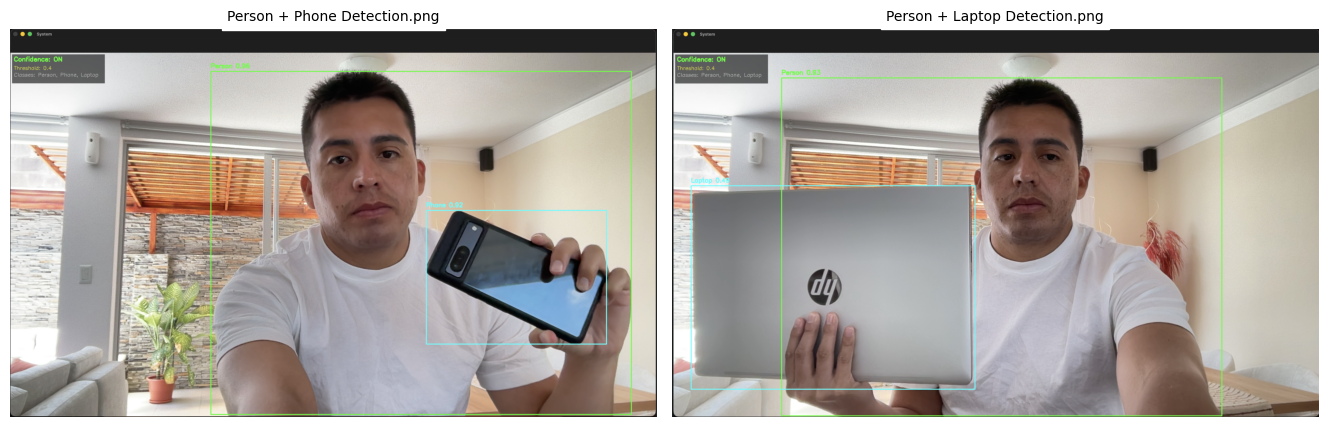

In [10]:
folder = "resources/on"

show_results(folder)

### *5.2 Clases Desactivadas*

En segunda instancia, se prueba la filtración de clases, de modo que el sistema muestre únicamente aquellas que están activas.

Para esta prueba se utilizaron objetos de las clases *botella y perro*, evidenciando que el sistema no los identifica al no estar habilitados.

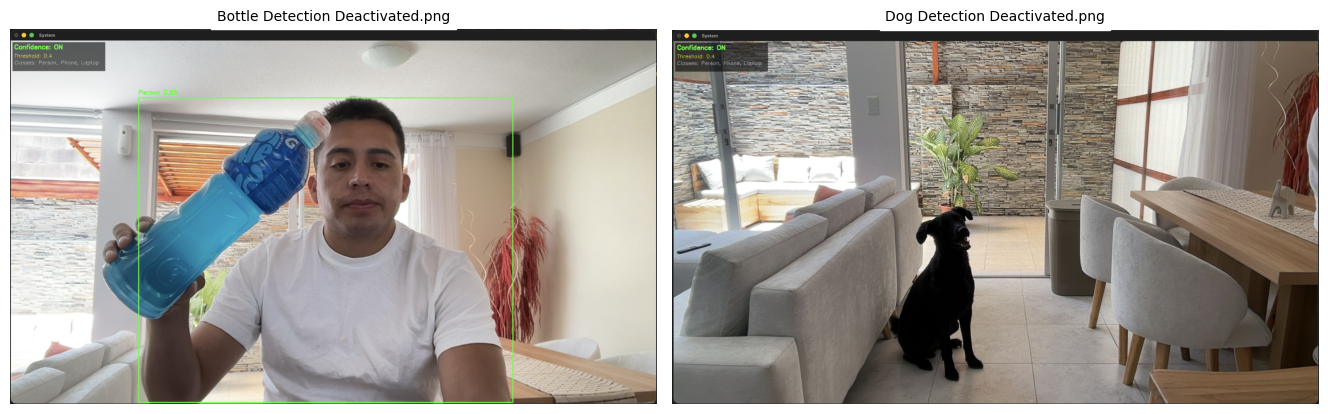

In [11]:
folder = "resources/off"

show_results(folder)

### *5.3 Clases Activas en Detección de Intrusión*

Finalmente, se muestra la solución completa del sistema de detección de intrusiones, donde el *usuario puede definir una zona de interés dibujándola directamente en la interfaz*.

Para este ejemplo se usan las clases *persona, laptop y zona de interés*, en donde el sistema es capaz de emitir una alerta cuando una persona ingresa al área definida.

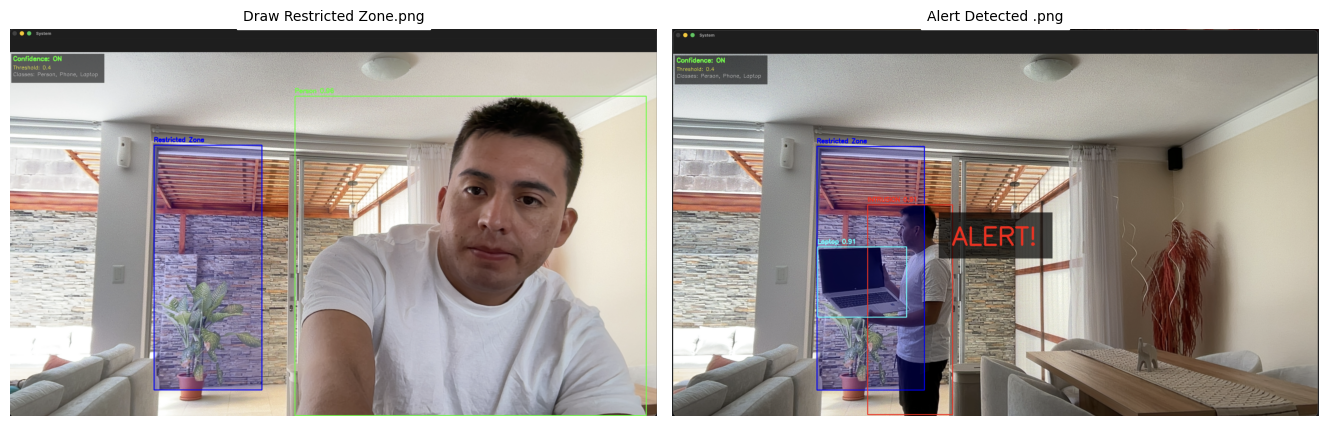

In [14]:
folder = "resources/intrusion"

show_results(folder)